# Time Series Analysis of Tree Growth Patterns Over Time Using Dendrometer Data
### Shannon McFarland
### 5/31/26

<hr style="border:2px solid black">

### Part 1: Exploratory Data Analysis (EDA)

In [1]:
# Import necessary libraries
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns


In [2]:
# Load cleaned lemon dendrometer dataset
lemon_df = pd.read_csv('cleaned_lemon1_2026-05-22.csv')

lemon_df

,Plant Name,Mountpoint Name,Serial Number,Sample Time (EST),cleaned:dendrometer
0,Lemon 1,1,A2084,5/6/24 13:20,3612
1,Lemon 1,1,A2084,5/6/24 13:25,3610
2,Lemon 1,1,A2084,5/6/24 13:30,3612
3,Lemon 1,1,A2084,5/6/24 13:35,3616
4,Lemon 1,1,A2084,5/6/24 13:40,3614
...,...,...,...,...,...
214788,Lemon 1,1,A2084,5/7/26 12:14,8242
214789,Lemon 1,1,A2084,5/7/26 12:19,8240
214790,Lemon 1,1,A2084,5/7/26 12:24,8239
214791,Lemon 1,1,A2084,5/7/26 12:29,8237


In [3]:
# Check for missing values
lemon_df.isna().sum()

Plant Name             0
Mountpoint Name        0
Serial Number          0
Sample Time (EST)      0
cleaned:dendrometer    0
dtype: int64

In [4]:
# Create new dataframe with only relevant columns
lemon_subset = lemon_df[['Sample Time (EST)', 'cleaned:dendrometer']]

# Rename dendrometer column for easier reference
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    lemon_subset.rename(columns={'cleaned:dendrometer': 'Dendrometer'}, inplace=True)

lemon_subset

,Sample Time (EST),Dendrometer
0,5/6/24 13:20,3612
1,5/6/24 13:25,3610
2,5/6/24 13:30,3612
3,5/6/24 13:35,3616
4,5/6/24 13:40,3614
...,...,...
214788,5/7/26 12:14,8242
214789,5/7/26 12:19,8240
214790,5/7/26 12:24,8239
214791,5/7/26 12:29,8237


In [5]:
# Check data type of 'Sample Time (EST)' column
lemon_subset['Sample Time (EST)'].dtype

<StringDtype(storage='python', na_value=nan)>

In [6]:
# Convert 'Sample Time (EST)' column to datetime format
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    lemon_subset['Sample Time (EST)'] = pd.to_datetime(lemon_subset['Sample Time (EST)'])

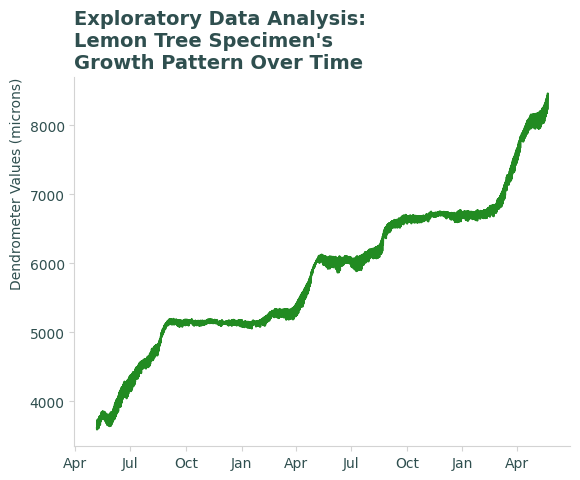

In [33]:
# Graph lemon tree's dendrometer measurements over time
lemon_lineplot = sns.lineplot(data=lemon_subset, x = 'Sample Time (EST)', y='Dendrometer', 
                              color = "forestgreen")

lemon_lineplot.xaxis.set_major_formatter(mdates.DateFormatter('%b')) # Month abbreviations on x-axis
lemon_lineplot.xaxis.set_major_locator(mdates.AutoDateLocator()) # Determines appropriate date intervals

sns.despine(top = True, right = True) # Remove top and rights spines from graph
plt.gca().spines["left"].set_color("lightgrey") # Change color of left spine
plt.gca().spines["bottom"].set_color("lightgrey") # Change color of bottom spine
plt.title("Exploratory Data Analysis: \nLemon Tree Specimen's \nGrowth Pattern Over Time", 
          loc = "left", fontsize = 14, fontweight = 'bold', color = "darkslategray")
plt.xlabel("")
plt.ylabel('Dendrometer Values (microns)', loc = "top", color ="darkslategray")
plt.tick_params(axis= "both", labelcolor = "darkslategray", color = "lightgrey") # Change color of tick mark labels
plt.show()

### Part 2: Data Preparation

In [20]:
# Correct for sensor error at 5/9/2025 7:17
# Sensor reading had a sudden increase from 6111 microns to 6367 microns in span of 5 minutes
# Subtract 256 microns from all measurements that time and after to correct for sensor error

lemon_subset.loc[lemon_subset['Sample Time (EST)'] >= '2025-05-09 07:17:00', 'Dendrometer'] -= 256
lemon_subset

,Sample Time (EST),Dendrometer
0,2024-05-06 13:20:00,3612
1,2024-05-06 13:25:00,3610
2,2024-05-06 13:30:00,3612
3,2024-05-06 13:35:00,3616
4,2024-05-06 13:40:00,3614
...,...,...
214788,2026-05-07 12:14:00,7986
214789,2026-05-07 12:19:00,7984
214790,2026-05-07 12:24:00,7983
214791,2026-05-07 12:29:00,7981


In [22]:
# Split data time into year, month, day columns
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    lemon_subset['Year'] = lemon_subset['Sample Time (EST)'].dt.year
    lemon_subset['Month'] = lemon_subset['Sample Time (EST)'].dt.month
    lemon_subset['Day'] = lemon_subset['Sample Time (EST)'].dt.day
lemon_subset

,Sample Time (EST),Dendrometer,Year,Month,Day
0,2024-05-06 13:20:00,3612,2024,5,6
1,2024-05-06 13:25:00,3610,2024,5,6
2,2024-05-06 13:30:00,3612,2024,5,6
3,2024-05-06 13:35:00,3616,2024,5,6
4,2024-05-06 13:40:00,3614,2024,5,6
...,...,...,...,...,...
214788,2026-05-07 12:14:00,7986,2026,5,7
214789,2026-05-07 12:19:00,7984,2026,5,7
214790,2026-05-07 12:24:00,7983,2026,5,7
214791,2026-05-07 12:29:00,7981,2026,5,7


In [23]:
# Group data by max dendrometer measurement for each day
lemon_groupby = lemon_subset.groupby(["Year","Month","Day"])['Dendrometer'].max().reset_index()
lemon_groupby

,Year,Month,Day,Dendrometer
0,2024,5,6,3693
1,2024,5,7,3732
2,2024,5,8,3739
3,2024,5,9,3743
4,2024,5,10,3773
...,...,...,...,...
742,2026,5,18,8330
743,2026,5,19,8366
744,2026,5,20,8393
745,2026,5,21,8425


In [24]:
# Find overall minimum dendrometer value in dataset
lemon_groupby['Dendrometer'].min()

np.int64(3693)

In [25]:
# Create new zeroed dendrometer column by subtracting minimum value from all measurements
lemon_groupby['Zeroed Dendrometer'] = lemon_groupby['Dendrometer'] - 3693
lemon_groupby

,Year,Month,Day,Dendrometer,Zeroed Dendrometer
0,2024,5,6,3693,0
1,2024,5,7,3732,39
2,2024,5,8,3739,46
3,2024,5,9,3743,50
4,2024,5,10,3773,80
...,...,...,...,...,...
742,2026,5,18,8330,4637
743,2026,5,19,8366,4673
744,2026,5,20,8393,4700
745,2026,5,21,8425,4732


In [26]:
# Combine year, month, day columns into new datetime column
lemon_groupby['Date'] = pd.to_datetime(lemon_groupby[['Year', 'Month', 'Day']])
lemon_groupby

,Year,Month,Day,Dendrometer,Zeroed Dendrometer,Date
0,2024,5,6,3693,0,2024-05-06
1,2024,5,7,3732,39,2024-05-07
2,2024,5,8,3739,46,2024-05-08
3,2024,5,9,3743,50,2024-05-09
4,2024,5,10,3773,80,2024-05-10
...,...,...,...,...,...,...
742,2026,5,18,8330,4637,2026-05-18
743,2026,5,19,8366,4673,2026-05-19
744,2026,5,20,8393,4700,2026-05-20
745,2026,5,21,8425,4732,2026-05-21


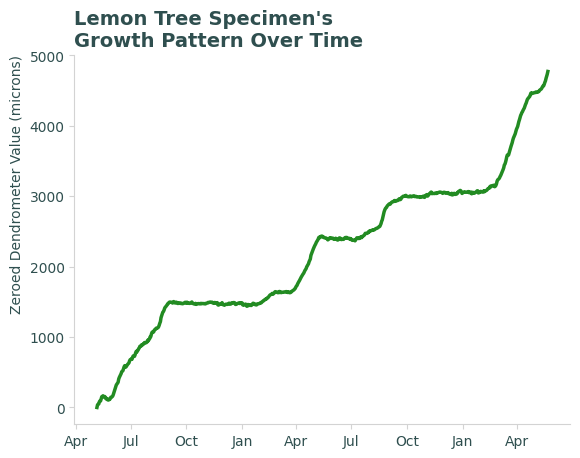

In [32]:
# Create new line graph with cleaned and zeroed dendrometer values
lemon_lineplot2 = sns.lineplot(data= lemon_groupby, x= "Date", y= "Zeroed Dendrometer", 
                               color = "forestgreen", linewidth = 2.5)

lemon_lineplot2.xaxis.set_major_formatter(mdates.DateFormatter('%b')) # Month abbreviations on x-axis
lemon_lineplot2.xaxis.set_major_locator(mdates.AutoDateLocator()) # Determines appropriate date intervals

sns.despine(top = True, right = True) # Remove top and rights spines from graph
plt.gca().spines["left"].set_color("lightgrey") # Change color of left spine
plt.gca().spines["bottom"].set_color("lightgrey") # Change color of bottom spine

plt.title("Lemon Tree Specimen's \nGrowth Pattern Over Time", 
          loc = "left", fontsize = 14, fontweight = 'bold', color = "darkslategray")
plt.xlabel("")
plt.ylabel('Zeroed Dendrometer Value (microns)', loc = "top", color ="darkslategray")
plt.tick_params(axis= "both", labelcolor = "darkslategray", color = "lightgrey") # Change color of tick mark labels
plt.show()

### Part 3: Model Selection

In [35]:
# Split data into training data set containing data from May 2024 to December2025
training_set = lemon_groupby[lemon_groupby['Date'] < '2026-01-01']

# Drop unnecessary columns from training set
training_set = training_set.drop(columns=['Year', 'Month', 'Day'])
# Reorder columns in training set
training_set = training_set[['Date', 'Zeroed Dendrometer']]
training_set

,Date,Zeroed Dendrometer
0,2024-05-06,0
1,2024-05-07,39
2,2024-05-08,46
3,2024-05-09,50
4,2024-05-10,80
...,...,...
600,2025-12-27,3070
601,2025-12-28,3082
602,2025-12-29,3077
603,2025-12-30,3061


In [36]:
# Split data into test data set containing data from January 2026 to May 2026
test_set = lemon_groupby[lemon_groupby['Date'] >= '2026-01-01']
# Drop unnecessary columns from test set
test_set = test_set.drop(columns=['Year', 'Month', 'Day'])
# Reorder columns in test set
test_set = test_set[['Date', 'Zeroed Dendrometer']]
test_set

,Date,Zeroed Dendrometer
605,2026-01-01,3046
606,2026-01-02,3053
607,2026-01-03,3057
608,2026-01-04,3063
609,2026-01-05,3060
...,...,...
742,2026-05-18,4637
743,2026-05-19,4673
744,2026-05-20,4700
745,2026-05-21,4732


In [37]:
# Use ADF (Augmented Dickey-Fuller) test to confirm if data set follows a non-stationary pattern
# If p-value > 0.05, then data follows a non-stationary trend

from statsmodels.tsa.stattools import adfuller

dftest = adfuller(training_set['Zeroed Dendrometer'], autolag='AIC')
print("1. ADF : ",dftest[0])
print("2. P-Value : ", dftest[1])
print("3. Num Of Lags : ", dftest[2])
print("4. Num Of Observations Used For ADF Regression and Critical Values Calculation :", dftest[3])

1. ADF :  -1.7232040210912567
2. P-Value :  0.41919845905530184
3. Num Of Lags :  9
4. Num Of Observations Used For ADF Regression and Critical Values Calculation : 595


In [38]:
# Since p-value is greater than 0.05, data follows a non-stationary trend
# Non-stationary trends needs to be addressed before modeling
# Convert to stationary data by differencing the data set

training_set['First_Difference'] = training_set[
    'Zeroed Dendrometer'] - training_set['Zeroed Dendrometer'].shift(1)

In [40]:
training_set

,Date,Zeroed Dendrometer,First_Difference
0,2024-05-06,0,NaN
1,2024-05-07,39,39.0
2,2024-05-08,46,7.0
3,2024-05-09,50,4.0
4,2024-05-10,80,30.0
...,...,...,...
600,2025-12-27,3070,1.0
601,2025-12-28,3082,12.0
602,2025-12-29,3077,-5.0
603,2025-12-30,3061,-16.0


In [39]:
# Retest ADF test to confirm if adjusted data is stationary
dftest = adfuller(training_set['First_Difference'].dropna(), autolag='AIC')
print("1. ADF : ",dftest[0])
print("2. P-Value : ", dftest[1])
print("3. Num Of Lags : ", dftest[2])
print("4. Num Of Observations Used For ADF Regression and Critical Values Calculation :", dftest[3])

1. ADF :  -4.4625377797544905
2. P-Value :  0.00022966983287509468
3. Num Of Lags :  8
4. Num Of Observations Used For ADF Regression and Critical Values Calculation : 595


*** p value is now < 0.05, indicating data is now following a stationary trend

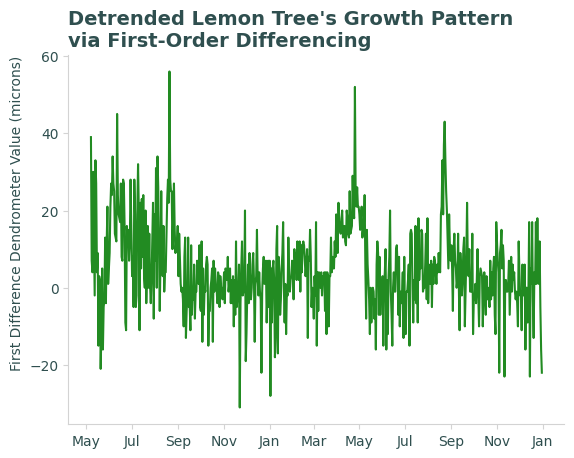

In [ ]:
# Graph differenced dendrometer values over time to confirm that data is now stationary
differencing_lineplot = sns.lineplot(data= training_set, x= "Date", y= "First_Difference", 
                                     color = "forestgreen")

differencing_lineplot.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
differencing_lineplot.xaxis.set_major_locator(mdates.AutoDateLocator())

sns.despine(top = True, right = True) # Remove top and rights spines from graph
plt.gca().spines["left"].set_color("lightgrey") # Change color of left spine
plt.gca().spines["bottom"].set_color("lightgrey") # Change color of bottom spine

plt.title("Detrended Lemon Tree's Growth Pattern \nvia First-Order Differencing", 
          loc = "left", fontsize = 14, fontweight = 'bold', color = "darkslategray")
plt.xlabel('')
plt.ylabel('First Difference Dendrometer Values (microns)', loc = "top", color ="darkslategray")
plt.tick_params(axis= "both", labelcolor = "darkslategray", color = "lightgrey") # Change color of tick mark labels

plt.show()

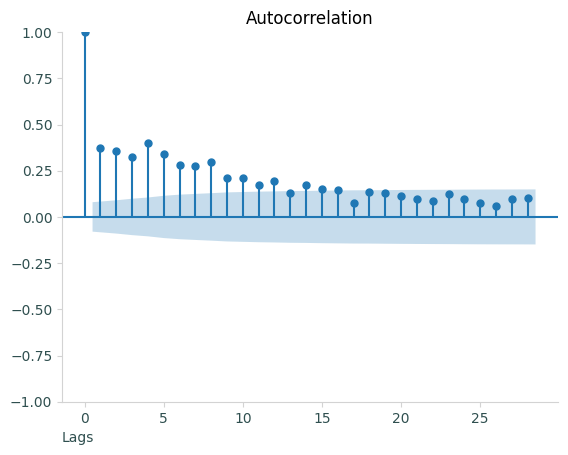

In [54]:
# Check for seasonality in data by graphing autocorrelation function (ACF) plot
# Checks for monthy seasonality
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(training_set['First_Difference'].dropna())

sns.despine(top = True, right = True) # Remove top and rights spines from graph
plt.gca().spines["left"].set_color("lightgrey") # Change color of left spine
plt.gca().spines["bottom"].set_color("lightgrey") # Change color of bottom spine

plt.xlabel('Lags', loc = "left", color ="darkslategray")
plt.tick_params(axis= "both", labelcolor = "darkslategray", color = "lightgrey") # Change color of tick mark labels

plt.show()

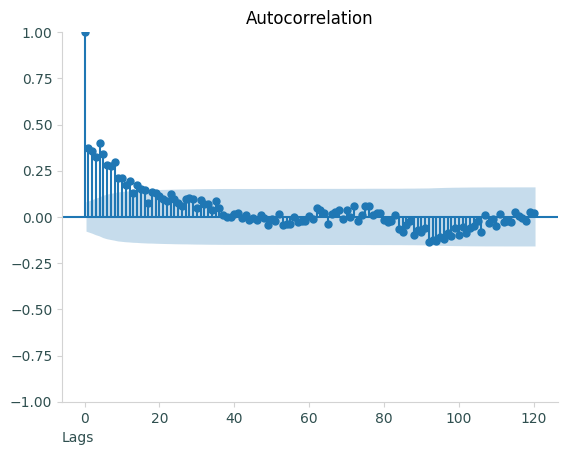

In [ ]:
# Check for seasonality in data by graphing autocorrelation plot
# Set lags to 120 to check for seasonality within 4 months

plot_acf(training_set['First_Difference'].dropna(), lags = 120)

sns.despine(top = True, right = True) # Remove top and rights spines from graph
plt.gca().spines["left"].set_color("lightgrey") # Change color of left spine
plt.gca().spines["bottom"].set_color("lightgrey") # Change color of bottom spine

plt.xlabel('Lags', loc = "left", color ="darkslategray")
plt.tick_params(axis= "both", labelcolor = "darkslategray", color = "lightgrey") # Change color of tick mark labels

plt.show()

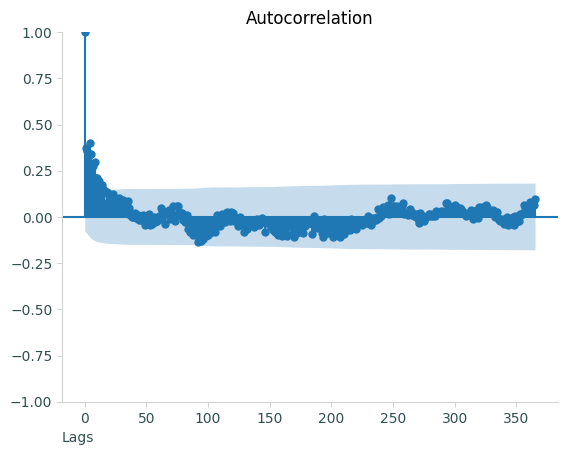

In [56]:
# Check for seasonality in data by graphing autocorrelation plot
# Set lags to 365 to check for seasonality within 1 year

plot_acf(training_set['First_Difference'].dropna(), lags = 365)

sns.despine(top = True, right = True) # Remove top and rights spines from graph
plt.gca().spines["left"].set_color("lightgrey") # Change color of left spine
plt.gca().spines["bottom"].set_color("lightgrey") # Change color of bottom spine

plt.xlabel('Lags', loc = "left", color ="darkslategray")
plt.tick_params(axis= "both", labelcolor = "darkslategray", color = "lightgrey") # Change color of tick mark labels

plt.show()

The autocorrelation function (ACF) plot demonstrates that the data does not have any significant seasonality even when the lags to check for seasonality with one month, four months, and year time period. While the data has some up and down wavering around the zero line, the majority of the data points are in the blue region. If there was significant seasonality present, there would be a consistent pattern of data points hovering above and below the blue region. Since there is no significant seasonality, the ARIMA model will be used to forecast the tree growth 
data. 

### Part 4: Model Building and Evaluation

In [82]:
# ARIMA (p, d, q)
# p = number of autoregressive terms or lag observations
# d = number of nonseasonal differences needed for stationarity 
# (Note: ADF determined only needed one difference for stationarity)
# q = size of the moving average (MA) or number of lagged forecast errors in the prediction equation


# Train ARIMA model setting p = 0, d = 1, q = 0
# Trend parameter set to 't' to account for increasing growth trend in data
from statsmodels.tsa.arima.model import ARIMA
arima_model = ARIMA(training_set['Zeroed Dendrometer'], order=(0,1,0), trend = 't')
arima_model_fit = arima_model.fit()

In [83]:
# Test ARIMA model by forecasting dendrometer measurements for test data time period
arima_forecast = arima_model_fit.get_forecast(steps=len(test_set))
arima_forecast_series = pd.Series(arima_forecast.predicted_mean, index = test_set.index)
test_set_comparison = pd.concat([test_set, arima_forecast_series], axis=1)
test_set_comparison

,Date,Zeroed Dendrometer,predicted_mean
605,2026-01-01,3046,3044.031452
606,2026-01-02,3053,3049.062904
607,2026-01-03,3057,3054.094356
608,2026-01-04,3063,3059.125808
609,2026-01-05,3060,3064.157259
...,...,...,...
742,2026-05-18,4637,3733.340362
743,2026-05-19,4673,3738.371814
744,2026-05-20,4700,3743.403266
745,2026-05-21,4732,3748.434718


In [ ]:
# Evaluate ARIMA model performance by calculating RMSE, MAE, and MAPE
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error 
from math import sqrt

arima_rmse = sqrt(mean_squared_error(test_set['Zeroed Dendrometer'], arima_forecast_series))
arima_mae = mean_absolute_error(test_set['Zeroed Dendrometer'], arima_forecast_series)
mape = mean_absolute_percentage_error(test_set['Zeroed Dendrometer'], arima_forecast_series)        


print("ARIMA RMSE: ", f"{arima_rmse:.2f}") # Set two decimal places
print("ARIMA MAE: ", f"{arima_mae:.2f}") # Set two decimal places
print("ARIMA MAPE: ", f"{mape*100:.2f}%") # Set two decimal places and convert MAPE to percentage

ARIMA RMSE:  493.37
ARIMA MAE:  368.09
ARIMA MAPE:  8.92%


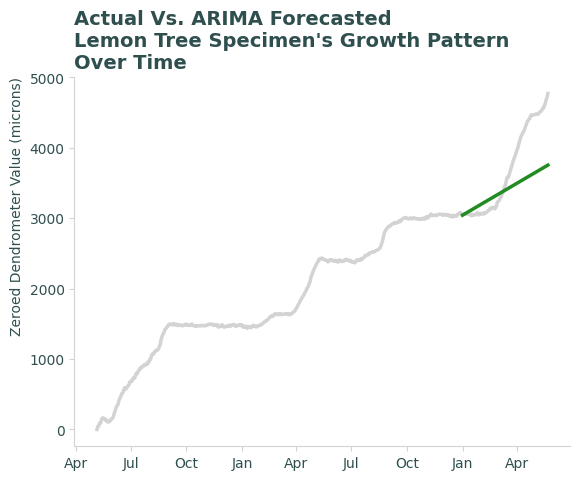

In [98]:
# Graph test and training data sets together with actual vs predicted values for test data time period

plt.plot(training_set['Date'], training_set['Zeroed Dendrometer'], label='Training Set Dendrometer Measurement', 
         color = "lightgrey", linewidth = 2.5)
plt.plot(test_set['Date'], test_set['Zeroed Dendrometer'], label='Test Set Dendrometer Measurement', color = "lightgrey", linewidth = 2.5)
plt.plot(test_set['Date'], arima_forecast_series, label='ARIMA Forecasted Dendrometer Measurement', color = "forestgreen", linewidth = 2.5)

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b')) # Month abbreviations on x-axis
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator()) # Determines appropriate date intervals

sns.despine(top = True, right = True) # Remove top and rights spines from graph
plt.gca().spines["left"].set_color("lightgrey") # Change color of left spine
plt.gca().spines["bottom"].set_color("lightgrey") # Change color of bottom spine

plt.title("Actual Vs. ARIMA Forecasted \nLemon Tree Specimen's Growth Pattern \nOver Time", 
          loc = "left", fontsize = 14, fontweight = 'bold', color = "darkslategray")

plt.xlabel("")
plt.ylabel('Zeroed Dendrometer Value (microns)', loc = "top", color ="darkslategray")
plt.tick_params(axis= "both", labelcolor = "darkslategray", color = "lightgrey") # Change color of tick mark labels

plt.show()
